In [13]:
import mlflow
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn import linear_model
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('SCD')


<Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1779782786199, experiment_id='0', last_update_time=1779786251550, lifecycle_stage='active', name='SCD', tags={}, trace_location=None, workspace='default'>

In [14]:
#Import data and convert the variable types to the correct format for modeling
scd = pd.read_excel('full_data.xlsx')
columns_to_clean = ['ACR','Creatinine','Alb/mg/l']
for col in columns_to_clean:
    if col in scd.columns:
        scd[col] = scd[col].astype(str).str.replace('<', '').str.replace('>', '')
scd['Creatinine'] = pd.to_numeric(scd['Creatinine'],errors = 'coerce')
scd['Alb/mg/l'] = pd.to_numeric(scd['Alb/mg/l'],errors = 'coerce')
scd['ACR'] = pd.to_numeric(scd['ACR'],errors = 'coerce')
# Clean and normalize GENDER values
scd['GENDER'] = scd['GENDER'].astype(str).str.strip().str.upper()
# Normalize common full words to single-letter codes
scd['GENDER'] = scd['GENDER'].replace({'FEMALE': 'F', 'MALE': 'M'})
# Set invalid/unknown genders to NaN
scd.loc[~scd['GENDER'].isin(['F','M']), 'GENDER'] = np.nan
scd['GENDER'] = scd['GENDER'].astype('category')

# Assign HMOX1 genotype based on allele values
scd['HMOX1 GENOTYPE'] = np.where(
    (scd['HMOX1 ALLELE 1'] < 25) & (scd['HMOX1 ALLELE 2'] < 25),
    'SS',
    np.where(
        (scd['HMOX1 ALLELE 1'] > 25) & (scd['HMOX1 ALLELE 2'] < 25),
        'LS',
        np.where(
            (scd['HMOX1 ALLELE 1'] < 25) & (scd['HMOX1 ALLELE 2'] > 25),
            'SL',
            np.where(
                (scd['HMOX1 ALLELE 1'] > 25) & (scd['HMOX1 ALLELE 2'] > 25),
                'LL',
                None
            )
        )
    )
)
scd['HMOX1 GENOTYPE'].value_counts()
scd['GENDER'].value_counts()
#scd.info()

#one-hot encode the categorical variables
scd1 = pd.get_dummies(scd, columns=['GENDER','APOL1 GENOTYPE','HMOX1 GENOTYPE'])
#Remove unneeded columns and columns with
#  clinical factors that are measured only on a few subjects
scd2= scd1.drop(columns=["BP","HEIGHT(cm)","DNA NUMBER","ACR_code","ETHNIC Group","HMOX1_code","LDH","Fetal Hb","Bili totale","bili DIRECT","BILI INDIRECT",'prot','GB/Nitr','HMOX1 ALLELE 1','HMOX1 ALLELE 2'])
scd2 = scd2.dropna(axis=0, how='any')





GFR                                  1.000000
APOL1 GENOTYPE_G1 HOMOZYGOUS         0.148852
APOL1 GENOTYPE_G1/G2 HETEROZYGOUS    0.142346
Creatinine                           0.133616
GENDER_M                             0.115299
HMOX1 GENOTYPE_LL                    0.110329
HMOX1 GENOTYPE_SS                    0.105207
DBP                                  0.092342
APOL1 GENOTYPE_G2 HOMOZYGOUS         0.047085
APOL1 GENOTYPE_G1 HETEROZYGOUS       0.046481
HEIGHT/m                             0.029856
WEIGHT/Kg                            0.021757
Alb/mg/l                             0.000845
SBP                                 -0.002163
AGE(Years)                          -0.017320
BMI (Kg/m2)                         -0.020363
APOL1 GENOTYPE_G2 HETEROZYGOUS      -0.025515
ACR                                 -0.029164
APOL1 GENOTYPE_NO DNA               -0.045932
Transfusion                         -0.085389
GENDER_F                            -0.115299
APOL1 GENOTYPE_WILD TYPE          

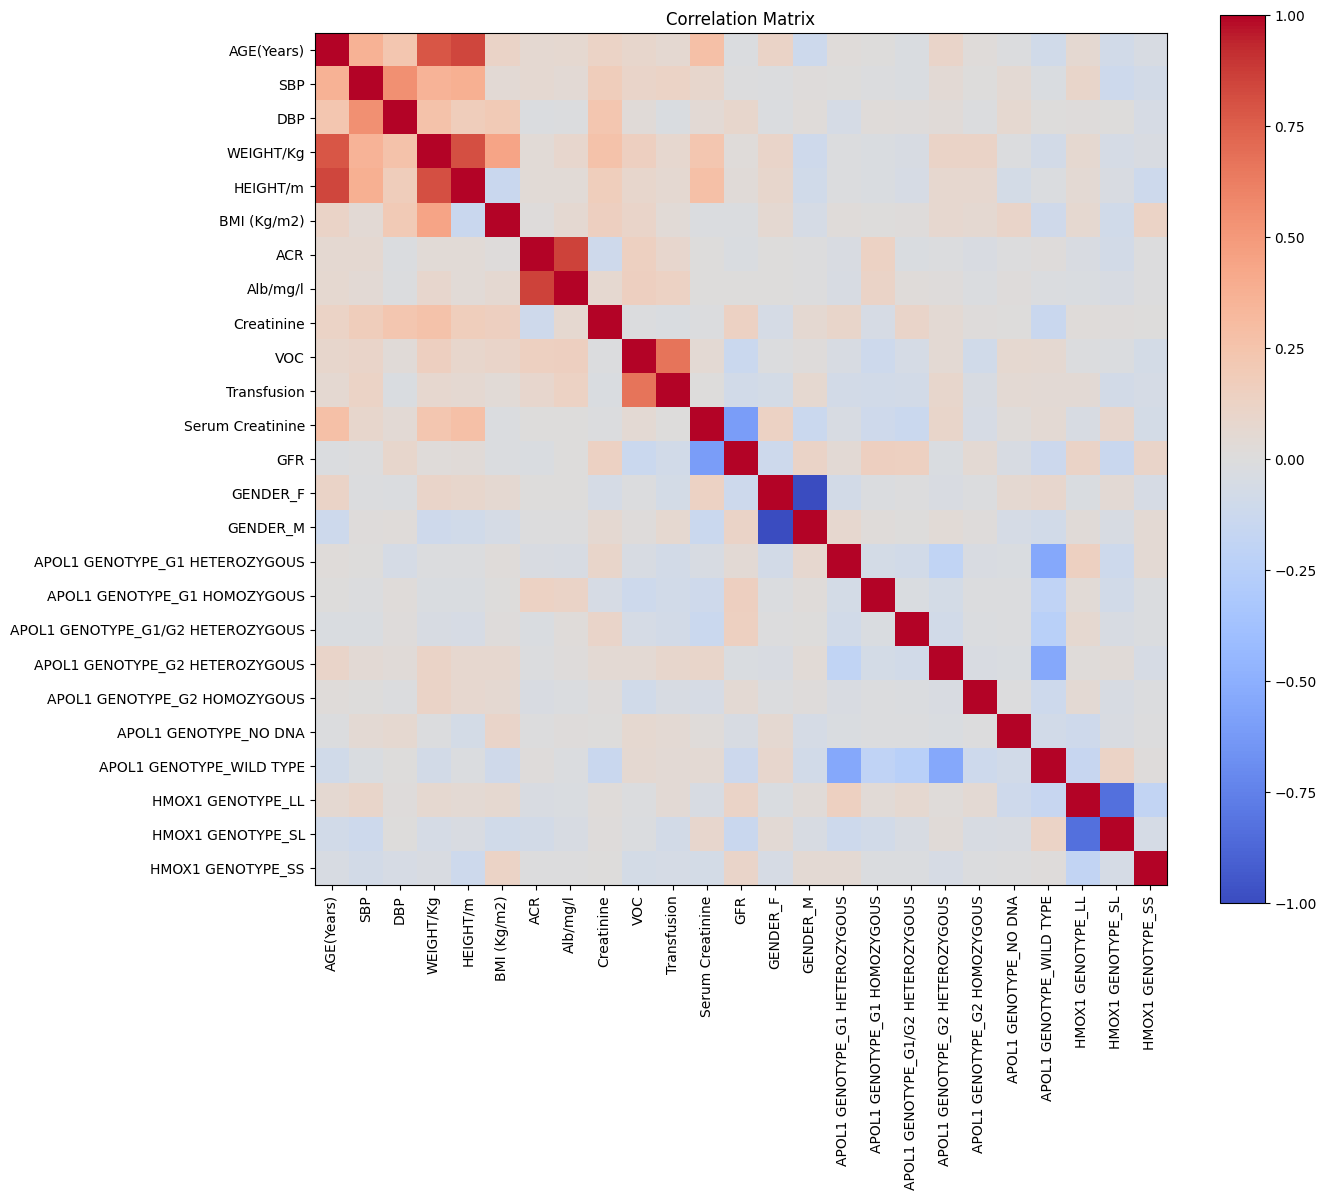

In [15]:
#check correlation of features with GFR and ACR
correlation_matrix = scd2.corr()
correlation_with_gfr = correlation_matrix['GFR'].sort_values(ascending=False)
print(correlation_with_gfr)
# Plot the correlation matrix
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None

plt.figure(figsize=(14,12))
if sns is not None:
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
else:
    plt.imshow(correlation_matrix, interpolation='nearest', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
    plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [16]:
X = scd2.drop(columns=["GFR"])
y = scd2['GFR']
X = X.dropna(axis=0, how='any')
#X.info()
X_train_df, X_test_df, Y_train_df, Y_test_df = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_df.info()

mlflow.sklearn.autolog()
model = linear_model.LinearRegression()
fitted_model = model.fit(X_train_df, Y_train_df)

print("Fitted model object:", fitted_model)
print("Coefficients:", fitted_model.coef_)
print("Intercept:", fitted_model.intercept_)
print("Train R^2:", fitted_model.score(X_train_df, Y_train_df))
print("Test R^2:", fitted_model.score(X_test_df, Y_test_df))

2026/06/03 15:15:59 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a0ded86dcda543579c5532c0ee3c747d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/03 15:15:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing V

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 141 to 104
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   AGE(Years)                         201 non-null    int64  
 1   SBP                                201 non-null    int64  
 2   DBP                                201 non-null    int64  
 3   WEIGHT/Kg                          201 non-null    float64
 4   HEIGHT/m                           201 non-null    float64
 5   BMI (Kg/m2)                        201 non-null    float64
 6   ACR                                201 non-null    float64
 7   Alb/mg/l                           201 non-null    float64
 8   Creatinine                         201 non-null    float64
 9   VOC                                201 non-null    int64  
 10  Transfusion                        201 non-null    int64  
 11  Serum Creatinine                   201 non-null    float64
 1

2026/06/03 15:16:03 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


Fitted model object: LinearRegression()
Coefficients: [-2.11667360e+00 -5.84849784e-01  1.15329164e+00  4.56880681e-01
  9.77841983e+01 -2.13270574e+00 -1.27397127e-01  1.81549120e-01
 -8.98359375e-03 -1.42357713e+00 -1.59726604e+00 -1.60818784e+02
 -2.24055293e+00  2.24055293e+00 -1.06134884e+01  5.10859455e+01
  1.87909476e+01 -1.27649701e+01 -2.36144300e+01  1.42108547e-14
 -2.28840047e+01  1.11195317e+01 -7.45451580e+00  2.21296018e+01]
Intercept: 132.48507347159762
Train R^2: 0.45779301042924636
Test R^2: 0.3806089873029387


In [6]:
alpha_values = [0.01, 0.05, 0.1, 0.5, 1.0]
for alpha in alpha_values:
    with mlflow.start_run():
        mlflow.set_tag('developer','Oluyomi')
        #mlflow.log_param('train-data-path', 'data/yellow_tripdata_2023-01.parquet')
        #mlflow.log_param('valid-data-path', 'data/yellow_tripdata_2023-02.parquet')
        alpha=0.01
        ls = linear_model.Lasso(alpha=alpha)
        ls.fit(X_train_df, Y_train_df)
        ls_rmse = mean_squared_error(Y_train_df, ls.predict(X_train_df))
        mlflow.log_metric('rmse',ls_rmse)
        print("Linear Regression MSE:", ls_rmse)
        print("Coefficients:", ls.coef_)
        print("Intercept:", ls.intercept_)
        print("Train R^2:", ls.score(X_train_df, Y_train_df))
        print("Test R^2:", ls.score(X_test_df, Y_test_df))

2026/06/03 14:54:11 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/03 14:54:11 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site

Linear Regression MSE: 2371.615140705608
Coefficients: [-2.48660670e+00 -5.64211753e-01  5.28297536e-01 -5.78494153e-01
 -7.10900082e+02  2.26413127e-01 -1.04975695e-01  1.56803984e-01
  2.26967375e-02 -3.72785345e+00 -9.23243933e-01 -1.50194445e+02
  8.72454866e+00 -1.05381649e+01  0.00000000e+00  2.74187322e+00
  6.67786859e+01  3.52421142e+01 -0.00000000e+00 -1.16607654e+01
  0.00000000e+00 -1.24015930e+01  5.18773650e+00 -7.18173855e+00
  3.94691432e+00]
Intercept: 74.33619166852955
Train R^2: 0.6045236123506097
Test R^2: 0.3577708895958739


2026/06/03 14:54:19 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`
2026/06/03 14:54:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing va

Linear Regression MSE: 2371.615140705608
Coefficients: [-2.48660670e+00 -5.64211753e-01  5.28297536e-01 -5.78494153e-01
 -7.10900082e+02  2.26413127e-01 -1.04975695e-01  1.56803984e-01
  2.26967375e-02 -3.72785345e+00 -9.23243933e-01 -1.50194445e+02
  8.72454866e+00 -1.05381649e+01  0.00000000e+00  2.74187322e+00
  6.67786859e+01  3.52421142e+01 -0.00000000e+00 -1.16607654e+01
  0.00000000e+00 -1.24015930e+01  5.18773650e+00 -7.18173855e+00
  3.94691432e+00]
Intercept: 74.33619166852955
Train R^2: 0.6045236123506097
Test R^2: 0.3577708895958739


2026/06/03 14:54:22 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`
2026/06/03 14:54:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing va

Linear Regression MSE: 2371.615140705608
Coefficients: [-2.48660670e+00 -5.64211753e-01  5.28297536e-01 -5.78494153e-01
 -7.10900082e+02  2.26413127e-01 -1.04975695e-01  1.56803984e-01
  2.26967375e-02 -3.72785345e+00 -9.23243933e-01 -1.50194445e+02
  8.72454866e+00 -1.05381649e+01  0.00000000e+00  2.74187322e+00
  6.67786859e+01  3.52421142e+01 -0.00000000e+00 -1.16607654e+01
  0.00000000e+00 -1.24015930e+01  5.18773650e+00 -7.18173855e+00
  3.94691432e+00]
Intercept: 74.33619166852955
Train R^2: 0.6045236123506097
Test R^2: 0.3577708895958739


2026/06/03 14:54:26 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`
2026/06/03 14:54:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing va

Linear Regression MSE: 2371.615140705608
Coefficients: [-2.48660670e+00 -5.64211753e-01  5.28297536e-01 -5.78494153e-01
 -7.10900082e+02  2.26413127e-01 -1.04975695e-01  1.56803984e-01
  2.26967375e-02 -3.72785345e+00 -9.23243933e-01 -1.50194445e+02
  8.72454866e+00 -1.05381649e+01  0.00000000e+00  2.74187322e+00
  6.67786859e+01  3.52421142e+01 -0.00000000e+00 -1.16607654e+01
  0.00000000e+00 -1.24015930e+01  5.18773650e+00 -7.18173855e+00
  3.94691432e+00]
Intercept: 74.33619166852955
Train R^2: 0.6045236123506097
Test R^2: 0.3577708895958739


2026/06/03 14:54:29 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


Linear Regression MSE: 2371.615140705608
Coefficients: [-2.48660670e+00 -5.64211753e-01  5.28297536e-01 -5.78494153e-01
 -7.10900082e+02  2.26413127e-01 -1.04975695e-01  1.56803984e-01
  2.26967375e-02 -3.72785345e+00 -9.23243933e-01 -1.50194445e+02
  8.72454866e+00 -1.05381649e+01  0.00000000e+00  2.74187322e+00
  6.67786859e+01  3.52421142e+01 -0.00000000e+00 -1.16607654e+01
  0.00000000e+00 -1.24015930e+01  5.18773650e+00 -7.18173855e+00
  3.94691432e+00]
Intercept: 74.33619166852955
Train R^2: 0.6045236123506097
Test R^2: 0.3577708895958739


In [17]:
#build a random forest regression model and compare performance to linear regression
with mlflow.start_run():
    mlflow.set_tag('developer','Oluyomi')
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train_df, Y_train_df)
    rf_predictions = rf_model.predict(X_test_df)
    rf_mse = mean_squared_error(Y_test_df, rf_predictions)
    print("Random Forest Regression MSE:", rf_mse)
    mlflow.log_metric('mse', rf_mse)
    accuracy_before = rf_model.score(X_test_df, Y_test_df)
    print(f'Accuracy before feature selection: {accuracy_before:.2f}')
    print("Random Forest Regression R^2:", rf_model.score(X_test_df, Y_test_df))
    print("Random Forest Regression train R^2:", rf_model.score(X_train_df, Y_train_df))
    mlflow.log_metric('r2', rf_model.score(X_test_df, Y_test_df))
    mlflow.log_metric('train_r2', rf_model.score(X_train_df, Y_train_df))
    #mlflow.log_metric('feature_importances', rf_model.feature_importances_)

2026/06/03 15:16:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/06/03 15:16:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/03 15:16:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because thes

Random Forest Regression MSE: 421.6081298831468
Accuracy before feature selection: 0.94
Random Forest Regression R^2: 0.9443487319864233
Random Forest Regression train R^2: 0.9912278623579439


In [18]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Select top N features (example selecting top 10 features)
top_features = feature_importance_df['Feature'][:10].values
X_train_selected = X_train_df[top_features]
X_test_selected = X_test_df[top_features]

                              Feature    Importance
11                   Serum Creatinine  8.516911e-01
4                            HEIGHT/m  6.019895e-02
2                                 DBP  2.758972e-02
3                           WEIGHT/Kg  1.774175e-02
8                          Creatinine  9.794294e-03
0                          AGE(Years)  8.789105e-03
1                                 SBP  4.655738e-03
5                         BMI (Kg/m2)  4.414375e-03
6                                 ACR  4.128942e-03
20           APOL1 GENOTYPE_WILD TYPE  2.876381e-03
10                        Transfusion  2.568806e-03
9                                 VOC  1.389471e-03
7                            Alb/mg/l  1.328719e-03
22                  HMOX1 GENOTYPE_SL  6.235898e-04
13                           GENDER_M  5.849828e-04
15       APOL1 GENOTYPE_G1 HOMOZYGOUS  4.952388e-04
16  APOL1 GENOTYPE_G1/G2 HETEROZYGOUS  3.534799e-04
12                           GENDER_F  2.331906e-04
14     APOL1

In [19]:
# Train the Random Forest model with selected features
rf_selected = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selected.fit(X_train_selected, Y_train_df)

# Evaluate the model
accuracy_after = rf_selected.score(X_test_selected, Y_test_df)
print(f'Accuracy after feature selection: {accuracy_after:.2f}')

2026/06/03 15:19:01 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4d2c10b3a7da4d86b2a229c96d50cb68', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/06/03 15:19:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/03 15:19:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site

Accuracy after feature selection: 0.94
